<a href="https://colab.research.google.com/github/ankitsingh910/used-car-price-prediction-ml/blob/main/PP_Used_Cars.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROJECT NAME
**SMART PRICE PREDICTION :** A Machine Learning Approach for Predicting Used Car Prices


 **Problem Statement:**

The leading used car seller faces the challenge of accurately predicting the prices of used cars in their inventory. With a diverse range of vehicles coming in, each with its unique set of characteristics and conditions, determining the optimal selling price becomes complex. The lack of a systematic approach to price prediction leads to inconsistencies, potentially resulting in either overpricing, leading to prolonged inventory turnover, or underpricing, resulting in revenue loss.

To address this challenge, the company seeks to develop a robust predictive model that leverages machine learning algorithms to accurately estimate the selling price of each used car in their inventory. This model should take into account various factors such as make, model, year of manufacture, mileage, condition, and market trends to generate reliable price predictions.

The goal is to streamline the pricing process, minimize guesswork, and optimize revenue generation by setting competitive yet profitable prices for each used car. By implementing an efficient pricing strategy, the company aims to enhance customer satisfaction, improve inventory turnover rate, and maximize profitability in the competitive used car market.

In [4]:
#libraries for data wrangling
import numpy as np
import pandas as pd

# Adding this to ignore future warnings
import warnings
warnings.filterwarnings("ignore")

#libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

#Calculate vif
from statsmodels.stats.outliers_influence import variance_inflation_factor

#libraies for scaling data
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

# Importing libraries for model implimentation
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Importing libraries for hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Improting library for saving model
import joblib

In [5]:
#load dataset
path = "/content/cardekho_dataset.csv"
df = pd.read_csv(path)

## Dataset Exploration

In [6]:
#print first 5 rows
df.head(5)

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [7]:
#total rows and columns
df.shape

(15411, 14)

In [8]:
#drop column 0 and car_name
df.drop(['Unnamed: 0', 'car_name'], axis=1, inplace = True)

In [9]:
df.head(2)

,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.7,796,46.3,5,120000
1,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.9,1197,82.0,5,550000


In [10]:
#check null values
df.isna().sum()

,0
brand,0
model,0
vehicle_age,0
km_driven,0
seller_type,0
fuel_type,0
transmission_type,0
mileage,0
engine,0
max_power,0


No Null values

In [11]:
#check for duplicate rows
df.duplicated().sum()

np.int64(167)

In [12]:
#drop duplicate rows
df.drop_duplicates(inplace= True)

In [13]:
#check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [14]:
#dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15244 entries, 0 to 15410
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand              15244 non-null  object 
 1   model              15244 non-null  object 
 2   vehicle_age        15244 non-null  int64  
 3   km_driven          15244 non-null  int64  
 4   seller_type        15244 non-null  object 
 5   fuel_type          15244 non-null  object 
 6   transmission_type  15244 non-null  object 
 7   mileage            15244 non-null  float64
 8   engine             15244 non-null  int64  
 9   max_power          15244 non-null  float64
 10  seats              15244 non-null  int64  
 11  selling_price      15244 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 1.5+ MB


In [15]:
# Display DataFrame without scientific notation
pd.options.display.float_format = '{:.4f}'.format

In [16]:
#dataset information
df.describe()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15244.0000,15244.0000,15244.0000,15244.0000,15244.0000,15244.0000,15244.0000
mean,6.0411,55639.5823,19.6973,1486.1715,100.6077,5.3262,774701.4481
std,3.0162,51766.2993,4.1693,520.4194,42.9157,0.8088,894676.0819
min,0.0000,100.0000,4.0000,793.0000,38.4000,0.0000,40000.0000
25%,4.0000,30000.0000,17.0000,1197.0000,74.0000,5.0000,385000.0000
50%,6.0000,50000.0000,19.6700,1248.0000,88.5000,5.0000,559000.0000
75%,8.0000,70000.0000,22.7000,1582.0000,117.3000,5.0000,825000.0000
max,29.0000,3800000.0000,33.5400,6592.0000,626.0000,9.0000,39500000.0000


In [17]:
#numerical columns
numerical_variables = df.describe().columns.to_list()
print(f"Numerical Variables: {numerical_variables}")

#categorical columns
categorical_variables  = list(set(df.columns.to_list()) - set(numerical_variables))
print(f"Categorical Variables: {categorical_variables}")

Numerical Variables: ['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']
Categorical Variables: ['brand', 'model', 'transmission_type', 'fuel_type', 'seller_type']


In [18]:
#total rows and columns
df.shape

(15244, 12)

**Data Decritption**

| Feature           | Description                                                               |
|-------------------|---------------------------------------------------------------------------|
| car_name          | Car's full name, including brand and specific model name.                 |
| brand             | Brand name of the particular car.                                        |
| model             | Exact model name of the car for a particular brand.                       |
| seller_type       | Type of seller selling the used car.                                      |
| fuel_type         | Type of fuel used in the used car being put up for sale.                  |
| transmission_type | Type of transmission used in the used car being put up for sale.          |
| vehicle_age       | Number of years since the car was bought.                                 |
| mileage           | Number of kilometers the car runs per liter.                              |
| engine            | Engine capacity of the car in cubic centimeters (cc).                     |
| max_power         | Maximum power produced by the car in brake horsepower (BHP).              |
| seats             | Total number of seats in the car.                                         |
| selling_price     | Sale price of the car as listed on the website.                           |


In [19]:
df['brand'].nunique()

32

In [20]:
#check for unique values
for col in df.columns.to_list():
  print(col," : ", df[col].nunique())
  print('-'*25)

brand  :  32
-------------------------
model  :  120
-------------------------
vehicle_age  :  24
-------------------------
km_driven  :  3688
-------------------------
seller_type  :  3
-------------------------
fuel_type  :  5
-------------------------
transmission_type  :  2
-------------------------
mileage  :  411
-------------------------
engine  :  110
-------------------------
max_power  :  342
-------------------------
seats  :  8
-------------------------
selling_price  :  1086
-------------------------


In [21]:
# Proportion of each unique values of categorical column
for col in categorical_variables:
    print(df[col].value_counts(normalize=True) * 100)
    print('---------------------------')

brand
Maruti          32.3603
Hyundai         19.3650
Honda            9.6825
Mahindra         6.5534
Toyota           5.1758
Ford             5.0905
Volkswagen       4.0278
Renault          3.4571
BMW              2.8601
Tata             2.7617
Skoda            2.1845
Mercedes-Benz    2.1779
Audi             1.2464
Datsun           1.1152
Jaguar           0.3805
Land Rover       0.3280
Jeep             0.2690
Kia              0.2099
Porsche          0.1378
Volvo            0.1312
MG               0.1246
Mini             0.1115
Nissan           0.0722
Lexus            0.0590
Isuzu            0.0459
Bentley          0.0197
Maserati         0.0131
ISUZU            0.0131
Ferrari          0.0066
Mercedes-AMG     0.0066
Rolls-Royce      0.0066
Force            0.0066
Name: proportion, dtype: float64
---------------------------
model
i20            5.8908
Swift Dzire    5.7400
Swift          5.0774
Alto           5.0380
City           4.9200
                ...  
Altroz         0.0066
C    

## EDA

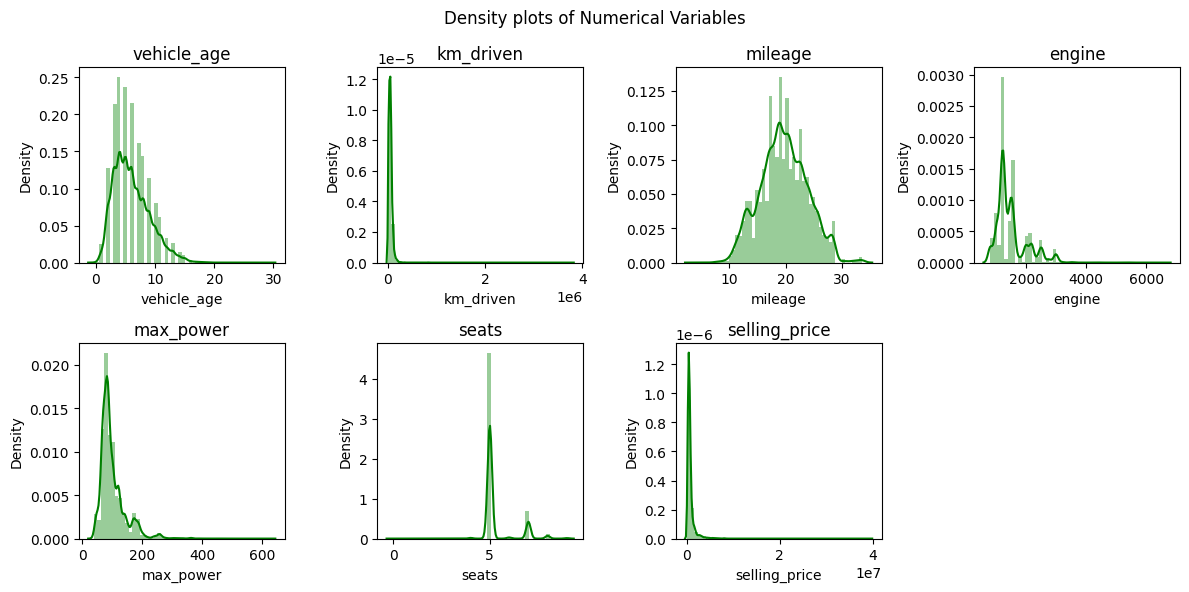

In [22]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(12, 6))
for i, col in enumerate(numerical_variables):
    ax = axes[i // 4, i % 4]
    sns.distplot(df[col], ax=ax, color='g')
    ax.set_title(col)
axes[1,3].axis('off')
plt.suptitle('Density plots of Numerical Variables')
plt.tight_layout()
plt.show()


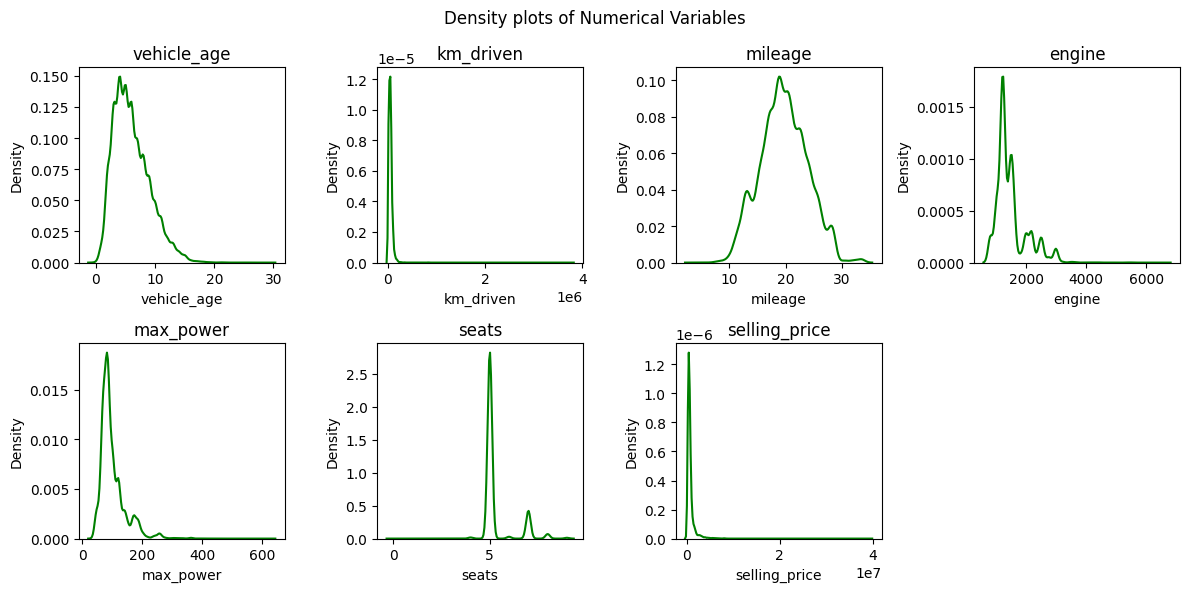

In [23]:
# kde plot for numerical_variables

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(12, 6))
for i, col in enumerate(numerical_variables):
    ax = axes[i // 4, i % 4]
    sns.kdeplot(df[col], ax=ax, color='g')
    ax.set_title(col)
axes[1,3].axis('off')
plt.suptitle('Density plots of Numerical Variables')
plt.tight_layout()
plt.show()


**Insights**
- Most cars have age less than 10 years.
- vehicle_age, km_driven, engine, max_power and selling_price have positively /right skewed distribution.

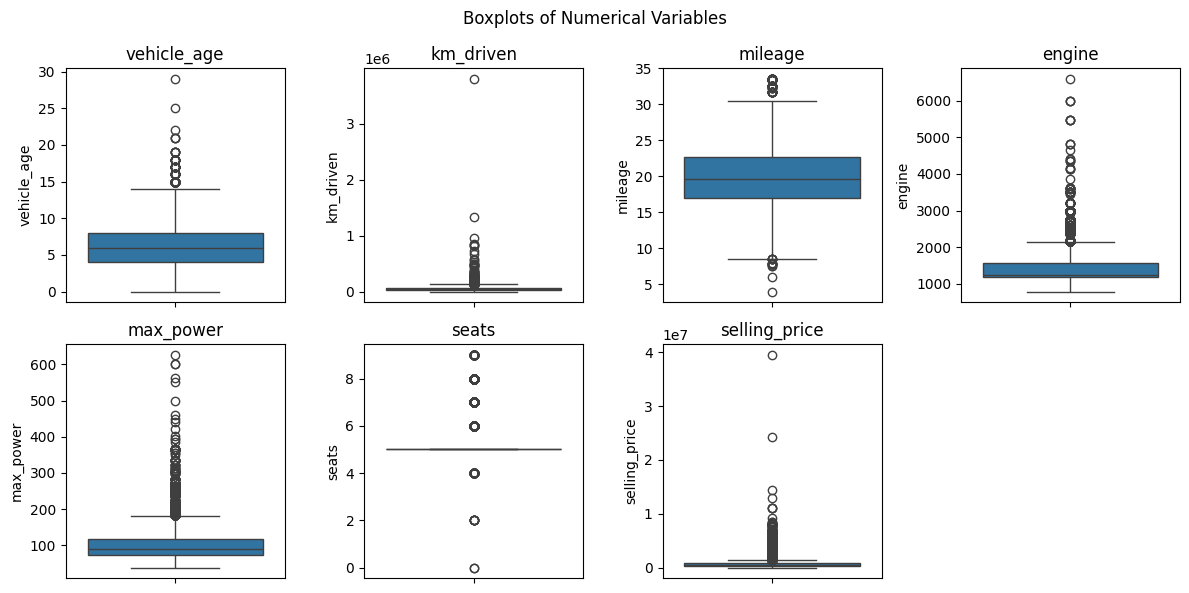

In [24]:
# Boxplots for numerical variables

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(12, 6))
for i, col in enumerate(numerical_variables):
    ax = axes[i // 4, i % 4]
    sns.boxplot(df[col], ax=ax)
    ax.set_title(col)
axes[1,3].axis('off') #turn off axis for last plot
plt.suptitle('Boxplots of Numerical Variables')
plt.tight_layout()
plt.show()

**Insights**

- The selling price exhibits a wide range. Several outliers indicate particularly high prices. These outliers might represent luxury or premium vehicles.
-  There are outliers with exceptionally high mileage, powerful engines, km_driven and max_power.

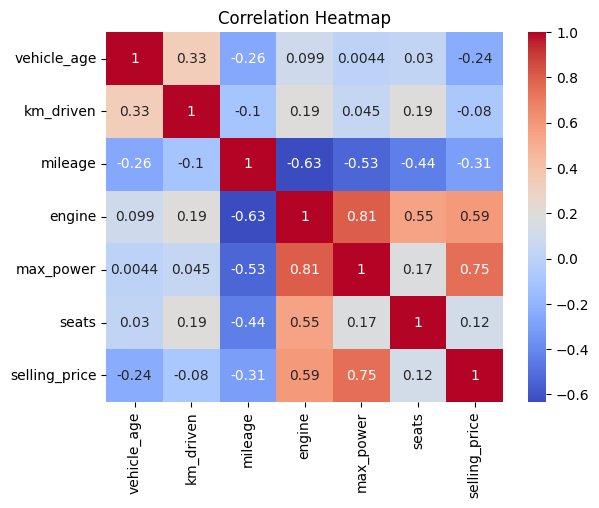

In [25]:
# Correlation matrix

correlation_matrix = df[numerical_variables].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

**Insights**
- Selling price, engine size and power has high positive linear correlation.
- Engine, power and mileage are negatively correlated.

In [26]:
numerical_variables

['vehicle_age',
 'km_driven',
 'mileage',
 'engine',
 'max_power',
 'seats',
 'selling_price']

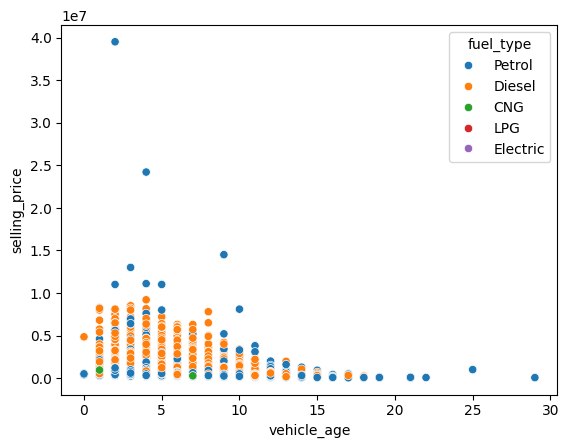

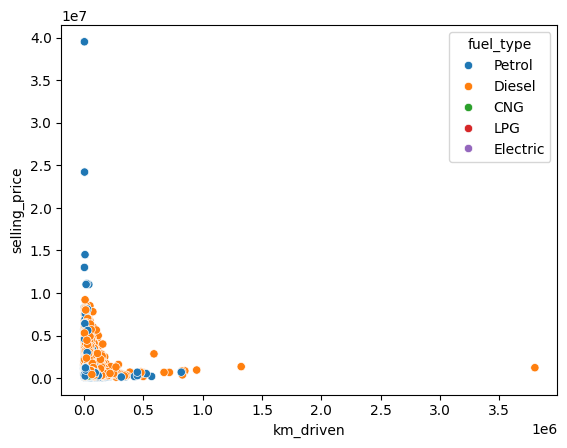

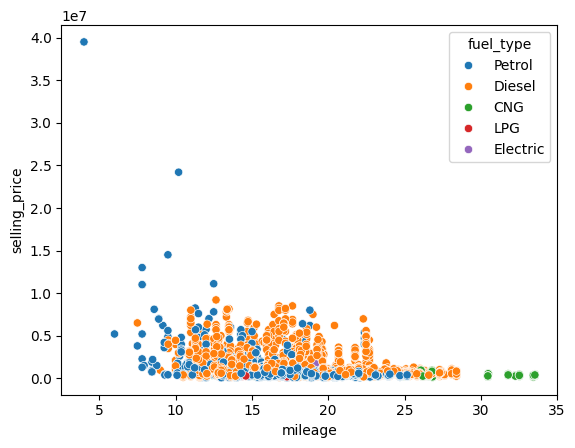

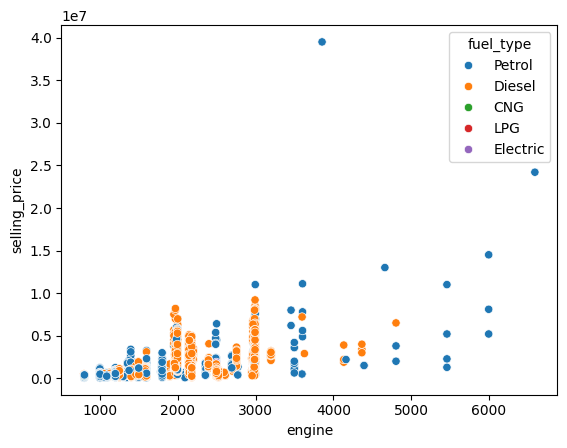

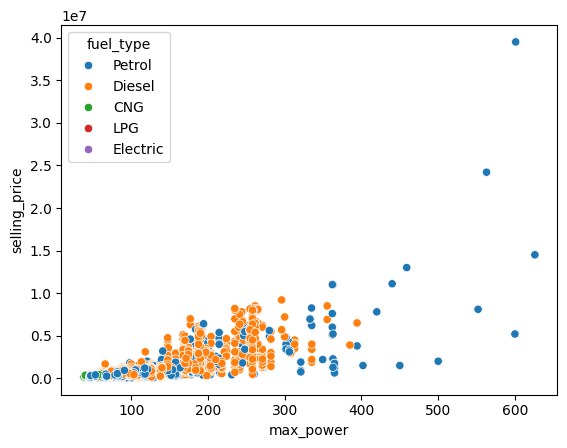

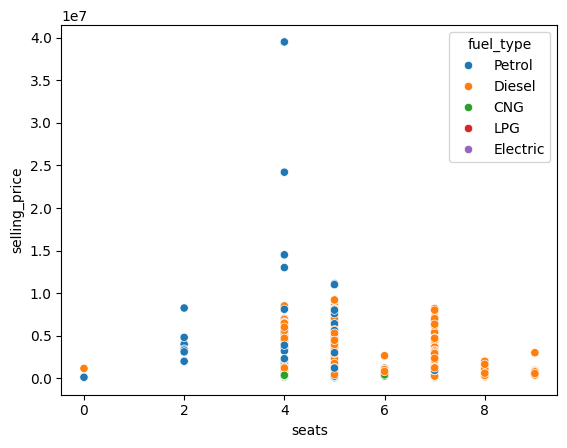

In [27]:
# Scater plot between numerical variable and selling_price
for col in ['vehicle_age','km_driven','mileage','engine','max_power','seats']:
  sns.scatterplot(data=df, x=col, y="selling_price", hue="fuel_type")
  plt.show()


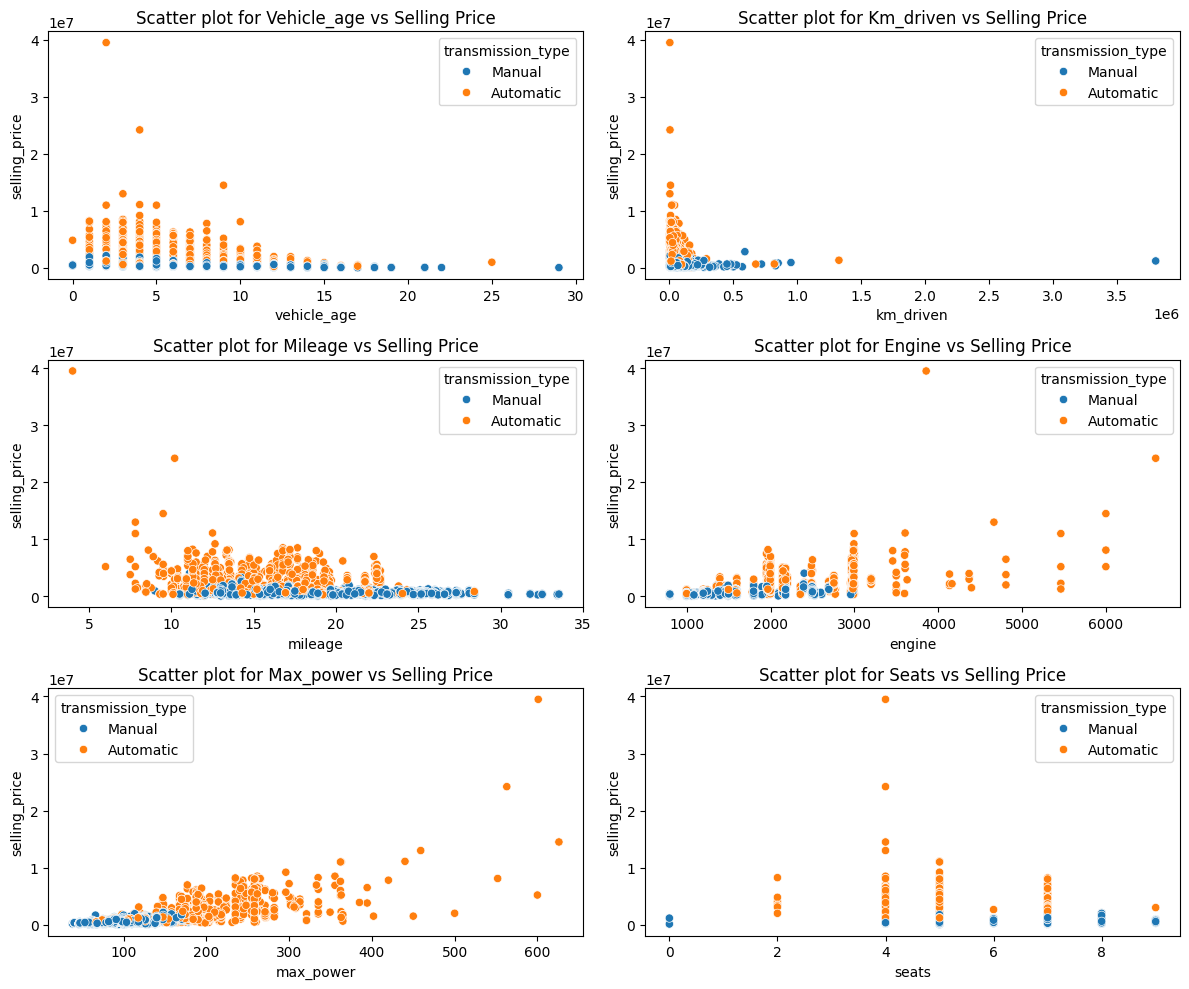

In [28]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 10))

for i, col in enumerate(['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']):
    row = i // 2
    cl = i % 2
    ax = axes[row, cl]
    sns.scatterplot(data=df, x=col, y="selling_price", hue='transmission_type', ax=ax)
    ax.set_title(f'Scatter plot for {col.capitalize()} vs Selling Price')

plt.tight_layout()
plt.show()

**Insights**
- Automatic cars have relatively high variation in selling price and also have high resale value.
- Manual cars are generally in affordable category.

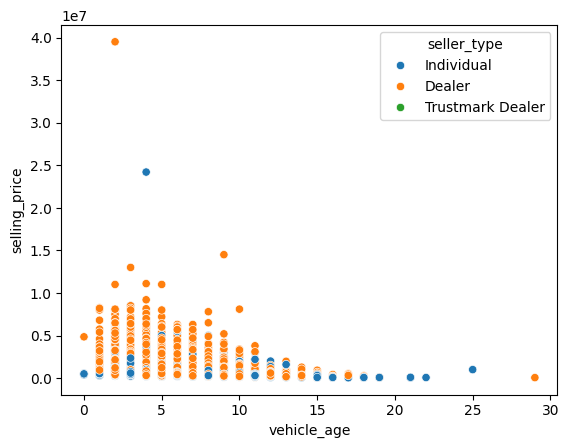

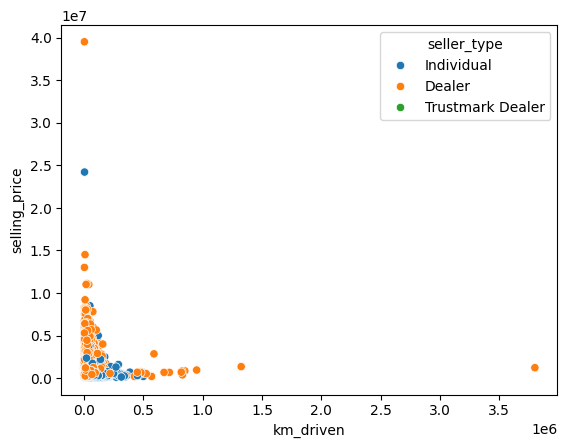

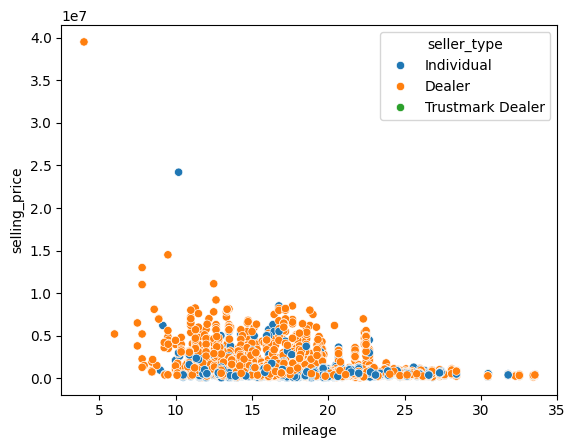

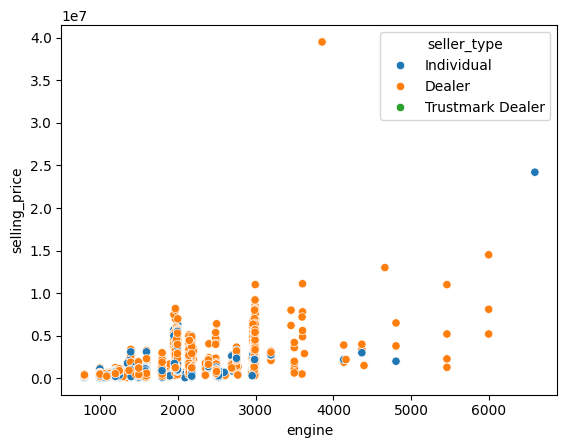

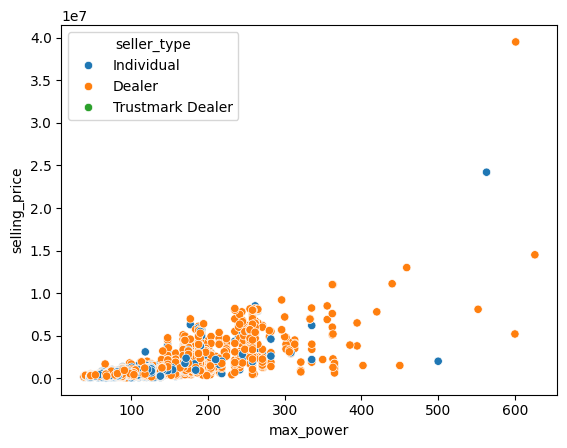

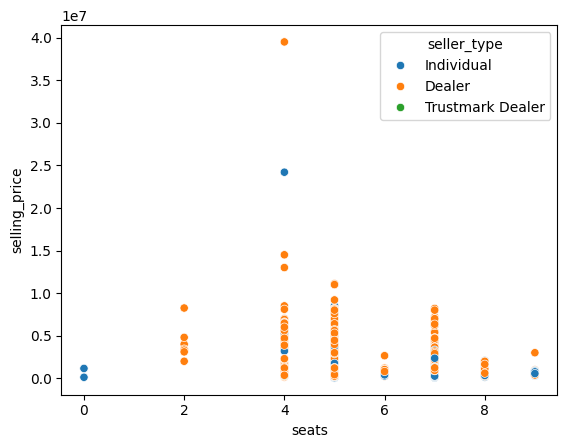

In [29]:
# Scater plot between numerical variable and selling_price
for col in ['vehicle_age','km_driven','mileage','engine','max_power','seats']:
  sns.scatterplot(data=df, x=col, y="selling_price", hue= 'seller_type')
  plt.show()

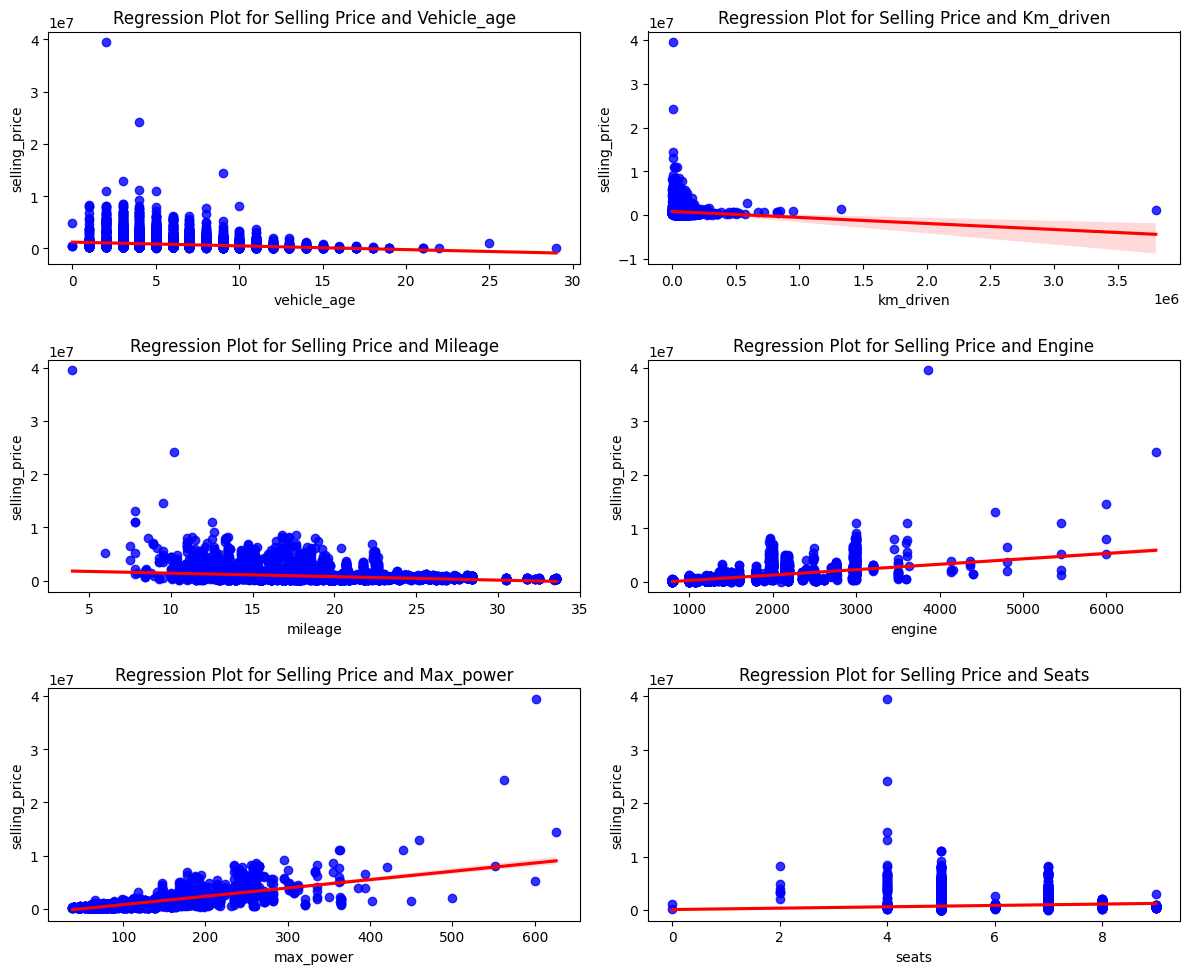

In [30]:
# Plot Rregression line plot for selling_price and numerical variables

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 10))

for i, col in enumerate(['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']):
    row = i // 2
    coln = i % 2
    ax = axes[row, coln]
    sns.regplot(x=df[col], y=df["selling_price"], scatter_kws={'color': 'blue'}, line_kws={'color': 'red'}, ax=ax)
    ax.set_title(f'Regression Plot for Selling Price and {col.capitalize()}')

plt.tight_layout()
plt.show()


## Feature Engineering

**Features**

**Numerical Variables**

In [31]:
numerical_variables

['vehicle_age',
 'km_driven',
 'mileage',
 'engine',
 'max_power',
 'seats',
 'selling_price']

**Categorical Variables**

In [32]:
categorical_variables

['brand', 'model', 'transmission_type', 'fuel_type', 'seller_type']

**Continuous Variables**

In [33]:
continuous_variables = [var for var in numerical_variables if df[var].nunique() >30]
continuous_variables

['km_driven', 'mileage', 'engine', 'max_power', 'selling_price']

**Check Outlier and Capping it**

In [34]:
#check percentage for outliers below lower limit and above upper limit
def check_outlier(col_list, data):
  outlier_percent_dict = {"variables":[], "%_Outliers_Below_Lower_Limit":[], "%_Outliers_Above_Upper_Limit":[]}
  for col in col_list:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_lim = Q1 - 1.5*IQR
    upper_lim = Q3 + 1.5*IQR

    lower_percent = round(data[data[col] < lower_lim].shape[0]/data[col].shape[0] *100,2)
    upper_percent = round(data[data[col] > upper_lim].shape[0]/data[col].shape[0] *100,2)

    outlier_percent_dict["variables"].append(col)
    outlier_percent_dict["%_Outliers_Below_Lower_Limit"].append(lower_percent)
    outlier_percent_dict["%_Outliers_Above_Upper_Limit"].append(upper_percent)

  #make dataframe
  outlier_percent_df = pd.DataFrame(outlier_percent_dict)

  return outlier_percent_df

In [35]:
check_outlier(continuous_variables,df)

,variables,%_Outliers_Below_Lower_Limit,%_Outliers_Above_Upper_Limit
0,km_driven,0.0000,3.0400
1,mileage,0.1000,0.4700
2,engine,0.0000,13.8000
3,max_power,0.0000,5.6000
4,selling_price,0.0000,8.9900


**Insights**
- Selling Price has approx 9% data above upper limit.
- Engine size has maximum 14% data above upper limit.

To avoide any loss in data we will not remove outliers but we will substitute outliers above upper limit with upper limit value.

In [36]:
df_new = df.copy()
for col in continuous_variables:
  Q1 = df_new[col].quantile(0.25)
  Q3 = df_new[col].quantile(0.75)
  IQR = Q3 - Q1

  upper_lim = Q3 + 1.5*IQR

  # Replace outliers exceeding the upper limit with the value of the upper limit
  df_new[col] = df_new[col].apply(lambda x: min(x, upper_lim))

In [37]:
check_outlier(continuous_variables,df_new)

,variables,%_Outliers_Below_Lower_Limit,%_Outliers_Above_Upper_Limit
0,km_driven,0.0000,0.0000
1,mileage,0.1000,0.0000
2,engine,0.0000,0.0000
3,max_power,0.0000,0.0000
4,selling_price,0.0000,0.0000


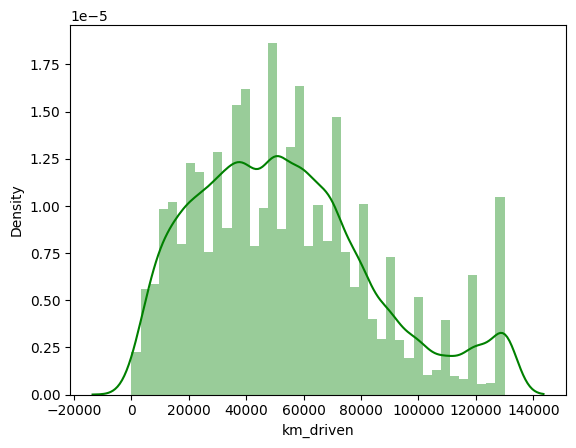

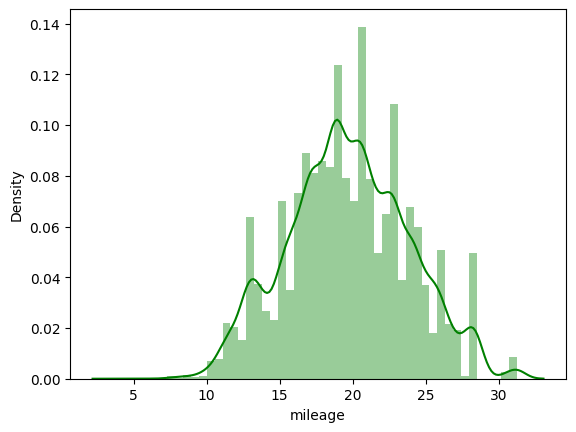

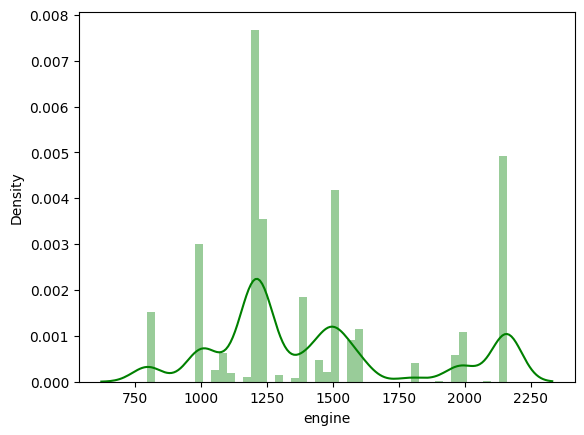

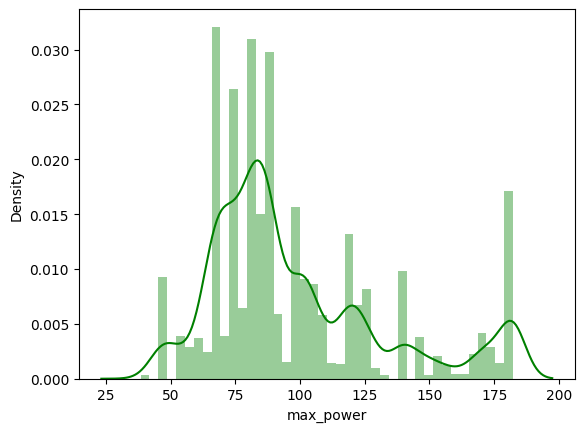

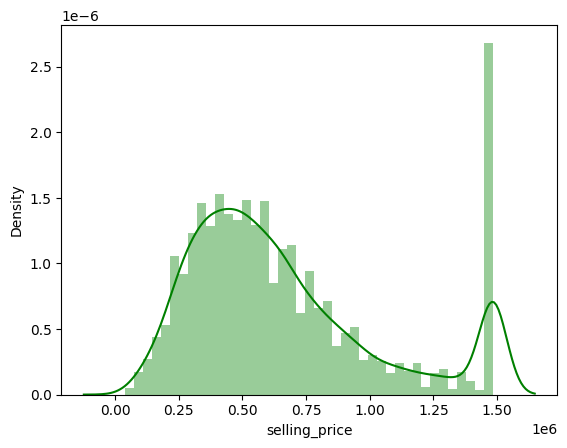

In [38]:
for var in continuous_variables:
  sns.distplot(df_new[var],color='g')
  plt.show()

**Categorical Encoding**

In [39]:
for var in categorical_variables:
  print(f"{var} has {df_new[var].nunique()} unique values")

brand has 32 unique values
model has 120 unique values
transmission_type has 2 unique values
fuel_type has 5 unique values
seller_type has 3 unique values


In [40]:
#drop model column
df_new.drop("model", axis=1, inplace=True)

use One-Hot Encoding

In [41]:
#using one-hot-encoding to encode the categorical variable
final_df = pd.get_dummies(df_new, dtype= int, drop_first=True)

In [42]:
#final dataset first rows
final_df.head(2)

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price,brand_BMW,brand_Bentley,brand_Datsun,...,brand_Toyota,brand_Volkswagen,brand_Volvo,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
0,9,120000.0000,19.7000,796.0000,46.3000,5,120000.0000,0,0,0,...,0,0,0,1,0,0,0,0,1,1
1,5,20000.0000,18.9000,1197.0000,82.0000,5,550000.0000,0,0,0,...,0,0,0,1,0,0,0,0,1,1


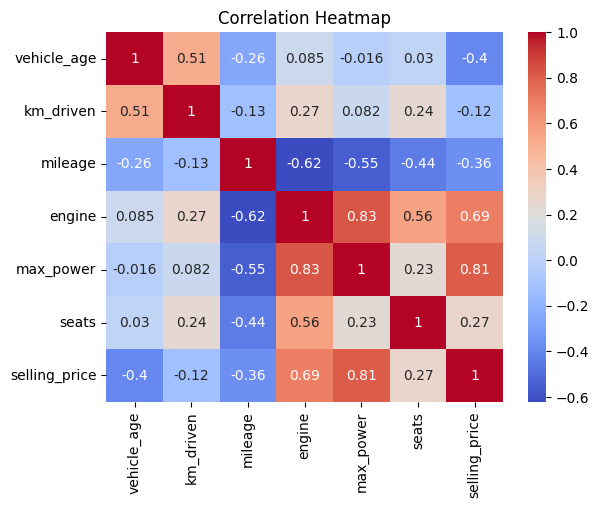

In [43]:
# Correlation matrix

correlation_matrix = final_df[numerical_variables].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [44]:
#import vif
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Define independent variable
independent_feature = list(set(final_df.columns) - {'selling_price'})
temp = final_df[independent_feature]

# Calculate VIF for each independent variable
vif = pd.DataFrame()
vif["Variable"] = temp.columns
vif["VIF"] = [variance_inflation_factor(temp.values, i) for i in range(temp.shape[1])]

# Display the VIF values
vif

,Variable,VIF
0,max_power,61.8267
1,brand_Maserati,1.0113
2,brand_Jaguar,1.2793
3,brand_Ferrari,1.0051
4,fuel_type_LPG,1.1358
5,brand_Kia,1.1645
6,seller_type_Trustmark Dealer,1.0372
7,fuel_type_Electric,1.0291
8,brand_ISUZU,1.0121
9,brand_Volvo,1.1026


In [45]:
#drop engine as hing VIF value and also with max_power
final_df.drop("engine",axis=1,inplace=True)

In [46]:
#import vif
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Define independent variable
independent_feature = list(set(final_df.columns) - {'selling_price'})
temp = final_df[independent_feature]

# Calculate VIF for each independent variable
vif = pd.DataFrame()
vif["Variable"] = temp.columns
vif["VIF"] = [variance_inflation_factor(temp.values, i) for i in range(temp.shape[1])]

# Display the VIF values
vif

,Variable,VIF
0,max_power,28.5109
1,brand_Maserati,1.0105
2,brand_Jaguar,1.2662
3,brand_Ferrari,1.0040
4,fuel_type_LPG,1.1358
5,brand_Kia,1.1633
6,seller_type_Trustmark Dealer,1.0366
7,fuel_type_Electric,1.0270
8,brand_ISUZU,1.0121
9,brand_Volvo,1.1025


In [47]:
#drop seats as high VIF value
final_df.drop("seats",axis=1,inplace=True)

In [48]:
#import vif
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Define independent variable
independent_feature = list(set(final_df.columns) - {'selling_price'})
temp = final_df[independent_feature]

# Calculate VIF for each independent variable
vif = pd.DataFrame()
vif["Variable"] = temp.columns
vif["VIF"] = [variance_inflation_factor(temp.values, i) for i in range(temp.shape[1])]

# Display the VIF values
vif

,Variable,VIF
0,max_power,21.3618
1,brand_Maserati,1.0101
2,brand_Jaguar,1.2532
3,brand_Ferrari,1.0040
4,fuel_type_LPG,1.1311
5,brand_Kia,1.1321
6,seller_type_Trustmark Dealer,1.0364
7,fuel_type_Electric,1.0244
8,brand_ISUZU,1.0076
9,brand_Volvo,1.0826


**Data Transformation**

Distribution of Features Before Transformation



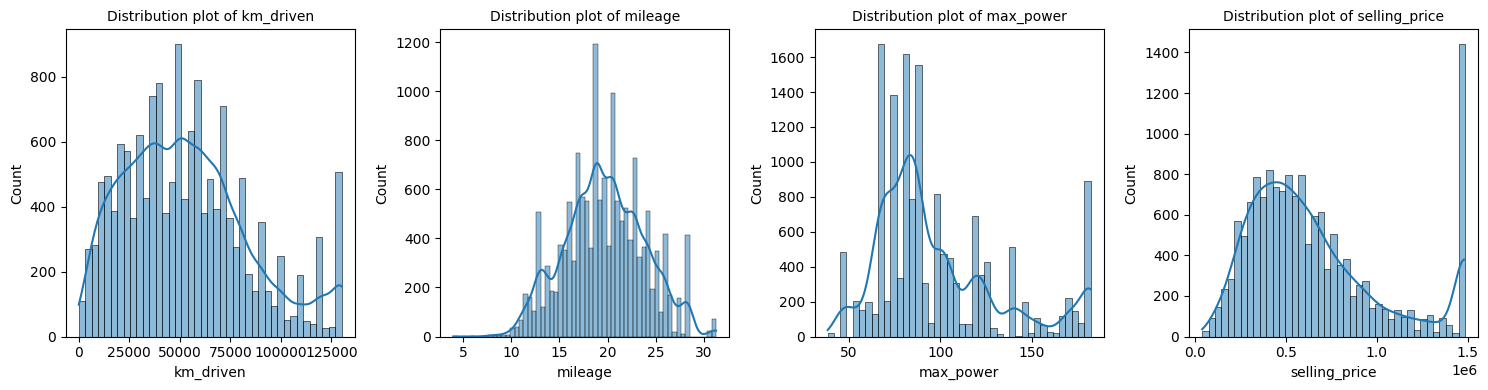

In [49]:
#check the distribution of continuous features
cont_features = ['km_driven', 'mileage', 'max_power', 'selling_price']

#distribution plot
print('Distribution of Features Before Transformation\n')
# Create a figure and axes for subplots
fig, axs = plt.subplots(1, 4, figsize=(15, 4))

# Loop through the features and create a displot for each
for i,feature in enumerate(cont_features):
  sns.histplot(final_df[feature],kde=True, ax=axs[i])
  axs[i].set_title(f'Distribution plot of {feature}', fontsize=10)

# Adjust the spacing between subplots
plt.tight_layout()

# Show the plots
plt.show()

In [50]:
#Using Square Root Transformation
final_df[cont_features] = np.sqrt(final_df[cont_features])

Distribution of Features After Transformation



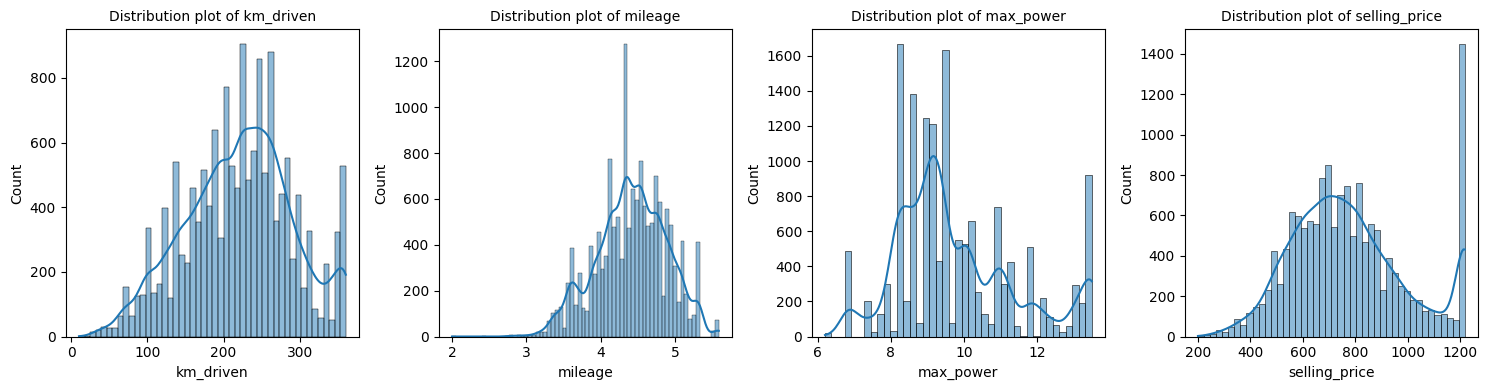

In [51]:
#distribution plot
print('Distribution of Features After Transformation\n')
# Create a figure and axes for subplots
fig, axs = plt.subplots(1, 4, figsize=(15, 4))

# Loop through the features and create a displot for each
for i,feature in enumerate(cont_features):
  sns.histplot(final_df[feature],kde=True, ax=axs[i])
  axs[i].set_title(f'Distribution plot of {feature}', fontsize=10)

# Adjust the spacing between subplots
plt.tight_layout()

# Show the plots
plt.show()

**Data Scaling**

In [52]:
# Scaling your data
#seperate data for dependent and independent features

# Define dependent variable (y)
dependent_feature = 'selling_price'
y = final_df[dependent_feature]

# Define independent variable (X)
columns = final_df.columns.to_list()
columns.remove('selling_price')
independent_feature = columns
X = final_df[independent_feature]

In [53]:
#check shape
X.shape, y.shape

((15244, 42), (15244,))

In [54]:
#import StandardScaler library
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

**Data Splitting**

In [55]:
# Split your data to train and test. Choose Splitting ratio wisely.
#import train test split
from sklearn.model_selection import train_test_split

#split data in ratio of 80:20
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state =10)

**Model Development**

In [56]:
# importing libraries to check the accuracy
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_percentage_error

In [57]:
#define a DataFrame and store accuracy score in this DataFrame
#store the accuracy metric in data frame
accuracy_df = pd.DataFrame(columns=['Model_Name','MAE_train','MAE_test','RMSE_train','RMSE_test','r2_train','r2_test','Accuracy_%_train','Accuracy_%_test'])


In [58]:
#define a function for evaluation metric

def evaluation_metric(model_name, y_train_initial, y_train_pred, y_test_initial, y_test_pred):
  '''Function to calculate the evaluation metric for regression model and store the score in DataFrame
  '''
  print(f'Accuracy Metric for {model_name}')
  print("-"*50)

  #converting y to its actual value by squaring
  y_train_initial, y_train_pred ,y_test_initial, y_test_pred = y_train_initial**2, y_train_pred**2, y_test_initial**2, y_test_pred**2

  # mean_absolute_error
  MAE_train= mean_absolute_error(y_train_initial,y_train_pred)
  print("MAE on train is:" ,MAE_train)
  MAE_test= mean_absolute_error(y_test_initial,y_test_pred)
  print("MAE on test is:" ,MAE_test)

  print("-"*50)

  # mean_squared_error
  MSE_train= mean_squared_error(y_train_initial, y_train_pred)
  print("MSE on train is:" ,MSE_train)
  MSE_test  = mean_squared_error(y_test_initial, y_test_pred)
  print("MSE on test is:" ,MSE_test)

  print("-"*50)

  # root_mean_squared_error
  RMSE_train = np.sqrt(MSE_train)
  print("RMSE on train is:" ,RMSE_train)
  RMSE_test = np.sqrt(MSE_test)
  print("RMSE on test is:" ,RMSE_test)

  print("-"*50)

  # mean_absolute_percentage_error
  MAPE_train = MAE_train/ np.mean(y_train_initial)*100
  MAPE_test = MAE_test/ np.mean(y_test_initial)*100

  ## r2_score
  R2_train= r2_score(y_train_initial,y_train_pred)
  print("R2 on train is:" ,R2_train)
  R2_test= r2_score(y_test_initial,y_test_pred)
  print("R2 on test is:" ,R2_test)

  print("-"*50)

  Accuracy_train= 100- MAPE_train
  print("Accuracy of train is:" ,Accuracy_train, " %")
  Accuracy_test= 100- MAPE_test
  print("Accuracy of test is:" ,Accuracy_test, " %")

  print("-"*50)

  #store the accuracy metric in data frame
  # store score in list
  global accuracy_df
  scores=[model_name,MAE_train,MAE_test,RMSE_train,RMSE_test,R2_train,R2_test,Accuracy_train,Accuracy_test]

  # create a new row with the values
  new_row = pd.DataFrame([scores], columns=accuracy_df.columns)

  # concat the new row to the DataFrame
  accuracy_df = pd.concat([accuracy_df,new_row], ignore_index=True)

  # Set the display format for floating-point numbers to 4 decimal places
  pd.options.display.float_format = '{:.4f}'.format

**Linear Regression**

In [59]:
#import Linear Regression library
from sklearn.linear_model import LinearRegression

# ML Model - 1 Implementation
regressor = LinearRegression()

# Fit the Algorithm
regressor.fit(X_train,y_train)

# Predict on the model
y_train_regression_pred= regressor.predict(X_train)
y_test_regression_pred= regressor.predict(X_test)

In [60]:
# Visualizing evaluation Metric Score chart
evaluation_metric('Linear Regression',y_train, y_train_regression_pred, y_test, y_test_regression_pred)

Accuracy Metric for Linear Regression
--------------------------------------------------
MAE on train is: 96124.79285376835
MAE on test is: 98330.7448333133
--------------------------------------------------
MSE on train is: 17238108104.740273
MSE on test is: 17644666208.170753
--------------------------------------------------
RMSE on train is: 131293.97588899604
RMSE on test is: 132833.22704869724
--------------------------------------------------
R2 on train is: 0.8750650299841654
R2 on test is: 0.8746154306307021
--------------------------------------------------
Accuracy of train is: 85.30599899404834  %
Accuracy of test is: 85.15437036752252  %
--------------------------------------------------


**Elastic Net**

In [61]:
#import Elastic Net
from sklearn.linear_model import ElasticNet

# Create a Elastic Net Regression model
ela_net = ElasticNet()

# Define a parameter grid for GridSearchCV
parameters_elastic_net = {"alpha": [0.000025,0.00005,0.0001,0.0002], "max_iter":[100,200,500]}

# Create a GridSearchCV object to search for the best parameter
grid_elastic_net = GridSearchCV(ela_net,parameters_elastic_net, scoring='neg_mean_squared_error',cv=5)

# Fit the Algorithm
grid_elastic_net.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=ElasticNet(),
             param_grid={'alpha': [2.5e-05, 5e-05, 0.0001, 0.0002],
                         'max_iter': [100, 200, 500]},
             scoring='neg_mean_squared_error')

In [62]:
# Predict on the model

# Get the best estimator (fitted model with the best parameters)
best_elastic_net_model = grid_elastic_net.best_estimator_

# Get the best parameters
best_elastic_net_parameters = grid_elastic_net.best_params_

# Get the mean squared error (MSE) of the best model on the validation data
best_elastic_net_mse = -grid_elastic_net.best_score_

# Make train predictions using the best model
y_train_grid_elastic_net_pred = best_elastic_net_model.predict(X_train)

# Make test predictions using the best model
y_test_grid_elastic_net_pred = best_elastic_net_model.predict(X_test)

# Evaluate the best model (e.g., using mean squared error)
elastic_net_mse = mean_squared_error(y_test, y_test_grid_elastic_net_pred)

print("Best parameters:", best_elastic_net_parameters)
print("Best MSE on validation data:", best_elastic_net_mse)
print("MSE on the entire dataset using the best model:", elastic_net_mse)

Best parameters: {'alpha': 0.0002, 'max_iter': 200}
Best MSE on validation data: 6129.4969121011645
MSE on the entire dataset using the best model: 6142.1837016481095


In [63]:
# Calculating evaluation Metric Score chart
evaluation_metric('Elastic Net',y_train, y_train_grid_elastic_net_pred, y_test, y_test_grid_elastic_net_pred)

Accuracy Metric for Elastic Net
--------------------------------------------------
MAE on train is: 96120.42288390831
MAE on test is: 98323.23926285688
--------------------------------------------------
MSE on train is: 17235511191.750595
MSE on test is: 17639313057.84199
--------------------------------------------------
RMSE on train is: 131284.0858282168
RMSE on test is: 132813.07562827537
--------------------------------------------------
R2 on train is: 0.8750838513794442
R2 on test is: 0.8746534705936475
--------------------------------------------------
Accuracy of train is: 85.30666700424231  %
Accuracy of test is: 85.15550353212292  %
--------------------------------------------------


**Decision Tree Regression Model**

In [64]:
# import the Decision Tree regressor
from sklearn.tree import DecisionTreeRegressor

# create a regressor object
dtree_reg = DecisionTreeRegressor(max_depth=16)

# fit the regressor with X and Y data
dtree_reg.fit(X_train, y_train)

# predict on model
y_train_dtree_pred= dtree_reg.predict(X_train)
y_test_dtree_pred= dtree_reg.predict(X_test)

In [65]:
# Calculating evaluation Metric Score chart
evaluation_metric('Decision Tree',y_train, y_train_dtree_pred, y_test, y_test_dtree_pred)

Accuracy Metric for Decision Tree
--------------------------------------------------
MAE on train is: 27536.421092671113
MAE on test is: 76553.46669890954
--------------------------------------------------
MSE on train is: 2327132000.606554
MSE on test is: 14376979656.371746
--------------------------------------------------
RMSE on train is: 48240.356555549566
RMSE on test is: 119904.04353637014
--------------------------------------------------
R2 on train is: 0.983133870320797
R2 on test is: 0.8978359022620349
--------------------------------------------------
Accuracy of train is: 95.79067806313451  %
Accuracy of test is: 88.44222714247984  %
--------------------------------------------------


**Random Forest Regression Model**

In [66]:
# import the Random Forest Regressor library
from sklearn.ensemble import RandomForestRegressor

# Create a Random Forest Regressor
rf_regressor = RandomForestRegressor(n_estimators=50)

# fit the regressor with X and Y data
rf_regressor.fit(X_train, y_train)

# predict on model
y_train_rf_pred= rf_regressor.predict(X_train)
y_test_rf_pred= rf_regressor.predict(X_test)

In [67]:
# Calculating evaluation Metric Score chart
evaluation_metric('Random Forest',y_train, y_train_rf_pred, y_test, y_test_rf_pred)

Accuracy Metric for Random Forest
--------------------------------------------------
MAE on train is: 27037.24058712811
MAE on test is: 66832.34074087384
--------------------------------------------------
MSE on train is: 1702471589.7081347
MSE on test is: 9931841514.454466
--------------------------------------------------
RMSE on train is: 41261.01779777293
RMSE on test is: 99658.62488743494
--------------------------------------------------
R2 on train is: 0.9876611612062866
R2 on test is: 0.9294234497472486
--------------------------------------------------
Accuracy of train is: 95.86698469155824  %
Accuracy of test is: 89.9098885115491  %
--------------------------------------------------


In [68]:
# Create a Decision Tree Regressor
rf_grid_regressor = RandomForestRegressor()

# Define a grid of hyperparameters to search
param_grid = {
    'n_estimators': [50,100,200],
    'max_depth': [10,15,20],
    'min_samples_leaf': [1, 2]
}

# Initialize GridSearchCV
grid_rf = GridSearchCV(rf_grid_regressor, param_grid, scoring='neg_mean_squared_error', cv=3)

# Fit the grid search to the training data
grid_rf.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestRegressor(),
             param_grid={'max_depth': [10, 15, 20], 'min_samples_leaf': [1, 2],
                         'n_estimators': [50, 100, 200]},
             scoring='neg_mean_squared_error')

In [69]:
# Predict on the model

# Get the best estimator (fitted model with the best parameters)
best_grid_rf_model = grid_rf.best_estimator_

# Get the best parameters
best_grid_rf_parameters = grid_rf.best_params_

# Get the mean squared error (MSE) of the best model on the validation data
best_grid_rf_mse = -grid_rf.best_score_

# Make train predictions using the best model
y_train_grid_rf_pred = best_grid_rf_model.predict(X_train)

# Make test predictions using the best model
y_test_grid_rf_pred = best_grid_rf_model.predict(X_test)

# Evaluate the best model (e.g., using mean squared error)
grid_rf_mse = mean_squared_error(y_test, y_test_grid_rf_pred)

print("Best parameters:", best_grid_rf_parameters)
print("Best MSE on validation data:", best_grid_rf_mse)
print("MSE on the entire dataset using the best model:", grid_rf_mse)

Best parameters: {'max_depth': 15, 'min_samples_leaf': 2, 'n_estimators': 200}
Best MSE on validation data: 3551.979385768547
MSE on the entire dataset using the best model: 3481.1135249748477


In [70]:
# Calculating evaluation Metric Score chart
evaluation_metric('Random Forest GridSearch',y_train, y_train_grid_rf_pred, y_test, y_test_grid_rf_pred)

Accuracy Metric for Random Forest GridSearch
--------------------------------------------------
MAE on train is: 43336.18707827034
MAE on test is: 65195.03579996323
--------------------------------------------------
MSE on train is: 3941753065.037992
MSE on test is: 9459717398.869076
--------------------------------------------------
RMSE on train is: 62783.382077091
RMSE on test is: 97261.07854053992
--------------------------------------------------
R2 on train is: 0.9714317372882164
R2 on test is: 0.9327784057562278
--------------------------------------------------
Accuracy of train is: 93.37546581254088  %
Accuracy of test is: 90.15708304657869  %
--------------------------------------------------


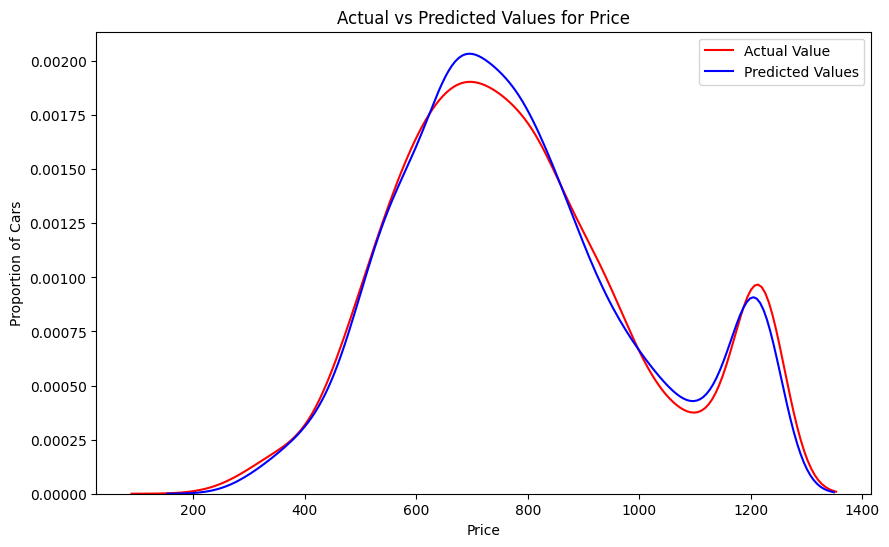

In [71]:
#distribution plot of y_test and y_predicted

plt.figure(figsize=(10, 6))
sns.distplot(y_test, hist=False, color="r", label="Actual Value")
sns.distplot(y_test_grid_rf_pred, hist=False, color="b", label="Predicted Values")
plt.title('Actual vs Predicted Values for Price')
plt.xlabel('Price')
plt.ylabel('Proportion of Cars')
plt.legend()
plt.show()

In [72]:
accuracy_df

,Model_Name,MAE_train,MAE_test,RMSE_train,RMSE_test,r2_train,r2_test,Accuracy_%_train,Accuracy_%_test
0,Linear Regression,96124.7929,98330.7448,131293.9759,132833.2270,0.8751,0.8746,85.3060,85.1544
1,Elastic Net,96120.4229,98323.2393,131284.0858,132813.0756,0.8751,0.8747,85.3067,85.1555
2,Decision Tree,27536.4211,76553.4667,48240.3566,119904.0435,0.9831,0.8978,95.7907,88.4422
3,Random Forest,27037.2406,66832.3407,41261.0178,99658.6249,0.9877,0.9294,95.8670,89.9099
4,Random Forest GridSearch,43336.1871,65195.0358,62783.3821,97261.0785,0.9714,0.9328,93.3755,90.1571


In [73]:
accuracy_df.drop(["MAE_train", "RMSE_train"], axis=1,inplace=True)

In [74]:
accuracy_df

,Model_Name,MAE_test,RMSE_test,r2_train,r2_test,Accuracy_%_train,Accuracy_%_test
0,Linear Regression,98330.7448,132833.2270,0.8751,0.8746,85.3060,85.1544
1,Elastic Net,98323.2393,132813.0756,0.8751,0.8747,85.3067,85.1555
2,Decision Tree,76553.4667,119904.0435,0.9831,0.8978,95.7907,88.4422
3,Random Forest,66832.3407,99658.6249,0.9877,0.9294,95.8670,89.9099
4,Random Forest GridSearch,65195.0358,97261.0785,0.9714,0.9328,93.3755,90.1571
